In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("/content/1776250375-P2-Healthcare Analytics for Doctor Visits.csv")

In [3]:
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5190
Number of columns: 13


In [5]:
df.shape

(5190, 13)

In [6]:
print("Columns in the dataset:")
for col in df.columns:
    print(col)

Columns in the dataset:
Unnamed: 0
visits
gender
age
income
illness
reduced
health
private
freepoor
freerepat
nchronic
lchronic


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [8]:
df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [9]:
df.describe(include='object')

,gender,private,freepoor,freerepat,nchronic,lchronic
count,5190,5190,5190,5190,5190,5190
unique,2,2,2,2,2,2
top,female,no,no,no,no,no
freq,2702,2892,4968,4099,3098,4585


In [10]:
df.isnull().sum()

,0
Unnamed: 0,0
visits,0
gender,0
age,0
income,0
illness,0
reduced,0
health,0
private,0
freepoor,0


In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

,0
Unnamed: 0,0.0
visits,0.0
gender,0.0
age,0.0
income,0.0
illness,0.0
reduced,0.0
health,0.0
private,0.0
freepoor,0.0


In [12]:
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [13]:
df = df.drop_duplicates()

In [14]:
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (5190, 13)


In [15]:
for col in df.columns:
    print("\n", col)
    print(df[col].unique())


 Unnamed: 0
[   1    2    3 ... 5188 5189 5190]

 visits
[1 2 3 4 8 5 7 6 9 0]

 gender
['female' 'male']

 age
[0.19 0.22 0.27 0.32 0.37 0.42 0.47 0.52 0.57 0.62 0.67 0.72]

 income
[0.55 0.45 0.9  0.15 0.35 0.65 0.25 0.   0.06 1.1  0.75 0.01 1.3  1.5 ]

 illness
[1 3 2 5 4 0]

 reduced
[ 4  2  0  5  1 13  7  3 14  6  8  9 10 12 11]

 health
[ 1  0  9  2  6  5  7 11  4 12  3 10  8]

 private
['yes' 'no']

 freepoor
['no' 'yes']

 freerepat
['no' 'yes']

 nchronic
['no' 'yes']

 lchronic
['no' 'yes']


In [16]:
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

df.head()

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [17]:
print(df.shape)
print(df.columns.tolist())

(5190, 12)
['visits', 'gender', 'age', 'income', 'illness', 'reduced', 'health', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']


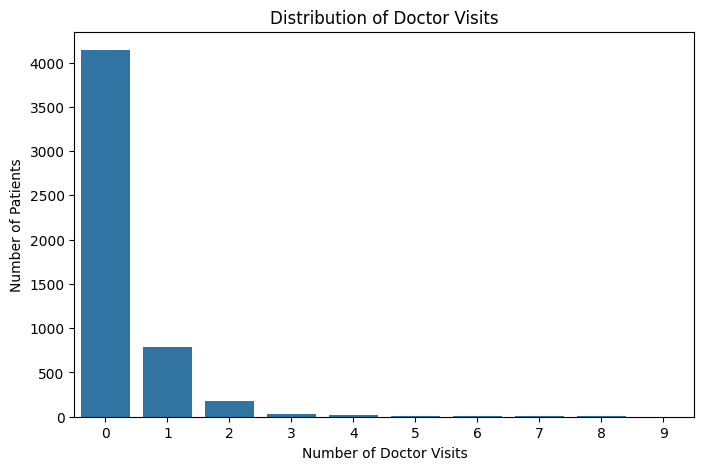

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='visits')

plt.title('Distribution of Doctor Visits')
plt.xlabel('Number of Doctor Visits')
plt.ylabel('Number of Patients')

plt.show()

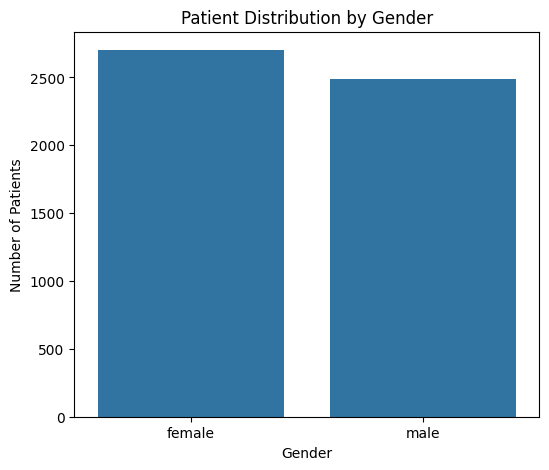

In [19]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='gender')

plt.title('Patient Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')

plt.show()

In [20]:
gender_visits = df.groupby('gender')['visits'].mean()

print(gender_visits)

gender
female    0.361954
male      0.236334
Name: visits, dtype: float64


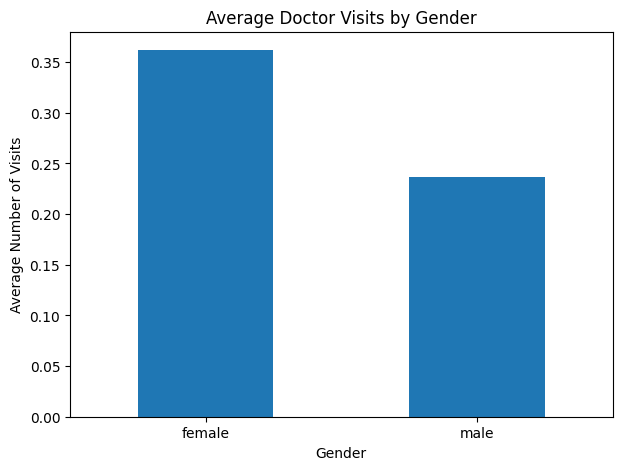

In [21]:
gender_visits.plot(kind='bar', figsize=(7,5))

plt.title('Average Doctor Visits by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Number of Visits')

plt.xticks(rotation=0)
plt.show()

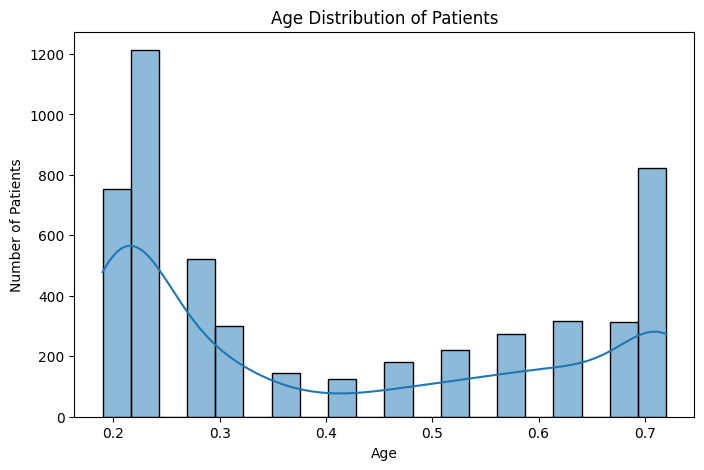

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='age', bins=20, kde=True)

plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Number of Patients')

plt.show()

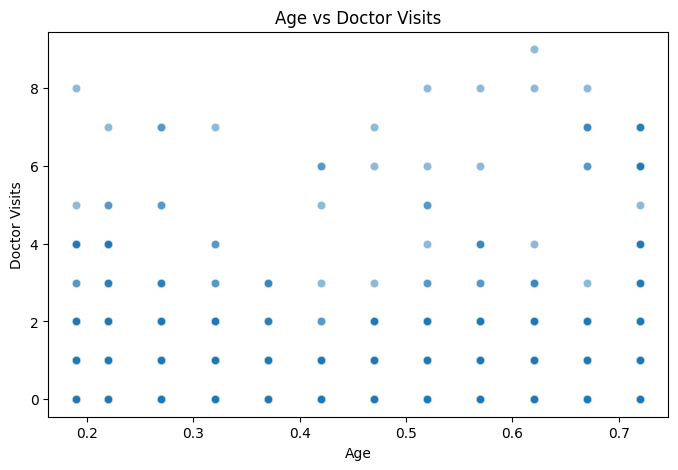

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='age', y='visits', alpha=0.5)

plt.title('Age vs Doctor Visits')
plt.xlabel('Age')
plt.ylabel('Doctor Visits')

plt.show()

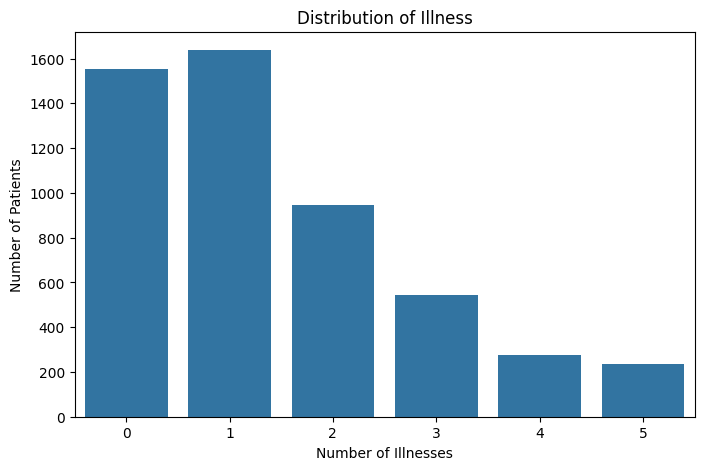

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='illness')

plt.title('Distribution of Illness')
plt.xlabel('Number of Illnesses')
plt.ylabel('Number of Patients')

plt.show()

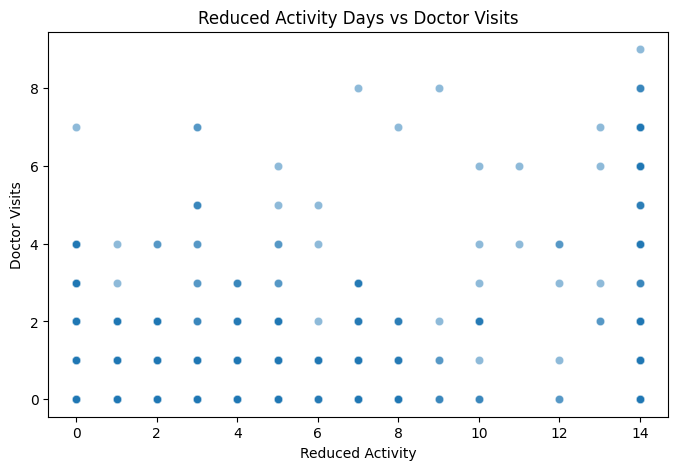

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='reduced', y='visits', alpha=0.5)

plt.title('Reduced Activity Days vs Doctor Visits')
plt.xlabel('Reduced Activity')
plt.ylabel('Doctor Visits')

plt.show()

In [26]:
correlation = df['reduced'].corr(df['visits'])

print("Correlation between reduced activity and doctor visits:", correlation)

Correlation between reduced activity and doctor visits: 0.4189544351604986


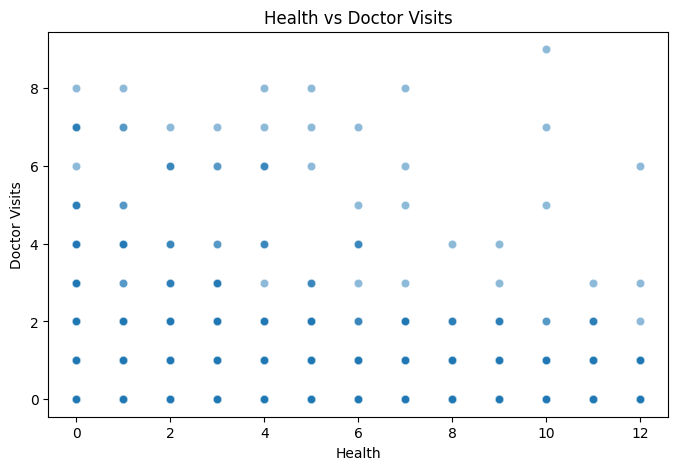

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='health', y='visits', alpha=0.5)

plt.title('Health vs Doctor Visits')
plt.xlabel('Health')
plt.ylabel('Doctor Visits')

plt.show()

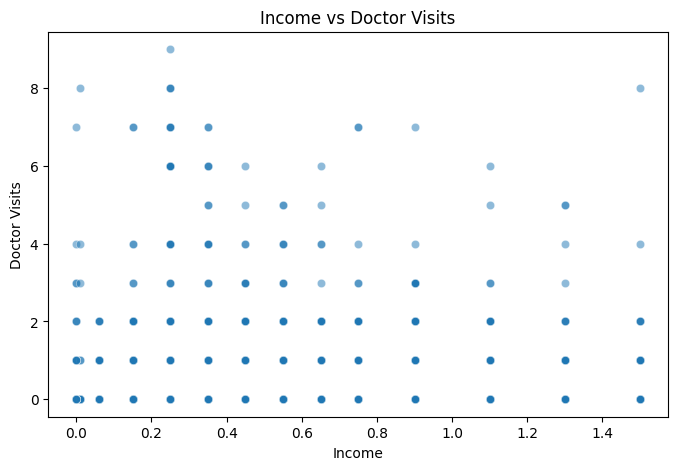

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='income', y='visits', alpha=0.5)

plt.title('Income vs Doctor Visits')
plt.xlabel('Income')
plt.ylabel('Doctor Visits')

plt.show()

In [29]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

correlation_matrix

,visits,age,income,illness,reduced,health
visits,1.000000,0.124537,-0.076840,0.223552,0.418954,0.193272
age,0.124537,1.000000,-0.271073,0.204984,0.094745,0.018616
income,-0.076840,-0.271073,1.000000,-0.148812,-0.047545,-0.085790
illness,0.223552,0.204984,-0.148812,1.000000,0.218116,0.360110
reduced,0.418954,0.094745,-0.047545,0.218116,1.000000,0.280208
health,0.193272,0.018616,-0.085790,0.360110,0.280208,1.000000


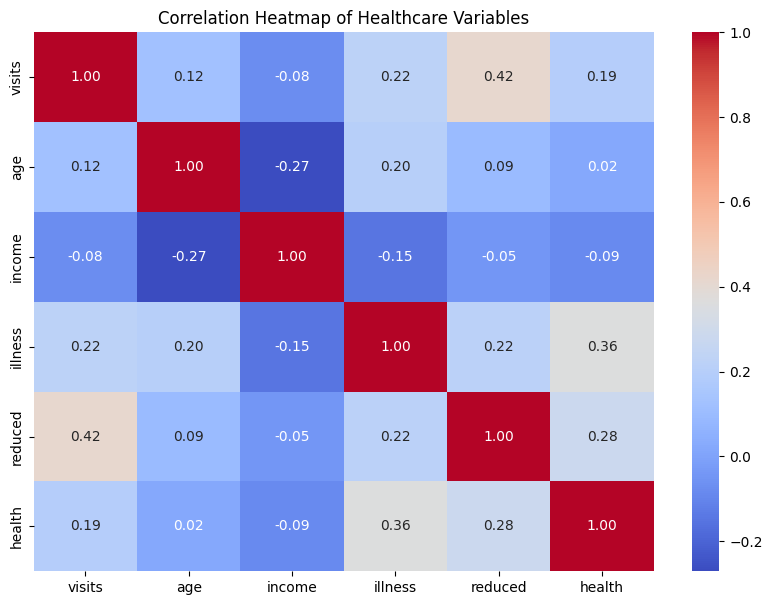

In [30]:
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Healthcare Variables')

plt.show()

In [31]:
visit_correlation = correlation_matrix['visits'].sort_values(
    ascending=False
)

print(visit_correlation)

visits     1.000000
reduced    0.418954
illness    0.223552
health     0.193272
age        0.124537
income    -0.076840
Name: visits, dtype: float64


In [32]:
print("Total patients:", len(df))
print("Total doctor visits:", df['visits'].sum())
print("Average doctor visits:", df['visits'].mean())
print("Maximum doctor visits:", df['visits'].max())
print("Minimum doctor visits:", df['visits'].min())

Total patients: 5190
Total doctor visits: 1566
Average doctor visits: 0.3017341040462428
Maximum doctor visits: 9
Minimum doctor visits: 0


In [33]:
zero_visits = (df['visits'] == 0).sum()
nonzero_visits = (df['visits'] > 0).sum()

print("Patients with 0 visits:", zero_visits)
print("Patients with at least 1 visit:", nonzero_visits)

print("Percentage with 0 visits:",
      round(zero_visits / len(df) * 100, 2), "%")

print("Percentage with at least 1 visit:",
      round(nonzero_visits / len(df) * 100, 2), "%")

Patients with 0 visits: 4141
Patients with at least 1 visit: 1049
Percentage with 0 visits: 79.79 %
Percentage with at least 1 visit: 20.21 %
